In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
d = pd.read_csv("diabetes_dirty_dataset.csv", usecols = range(1,15))
clean = pd.DataFrame(d)
clean.head(60)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0
5,2,197,88,29.0,170.0,47.0,2.107,58.0,217,135.3,75,32.1,8.6,1
6,6,80,77,17.0,119.0,33.2,1.020,24.0,181,136.7,79,NaN,5.5,0
7,2,79,69,25.0,61.0,26.4,0.668,32.0,211,144.1,86,44.0,3.4,0
8,5,NaN,108,53.0,215.0,33.8,2.265,63.0,160,143.8,60,18.5,9.0,1
9,9,180,103,23.0,336.0,47.9,1.577,51.0,230,141.7,98,53.8,0.8,1


In [3]:
# clean.info()
# clean.describe()
# clean.isnull().sum()
clean.duplicated().sum() #found 7 dupes
# clean[clean.duplicated()] #check the dupes
clean.drop_duplicates(inplace= True)

Initial rows: 999


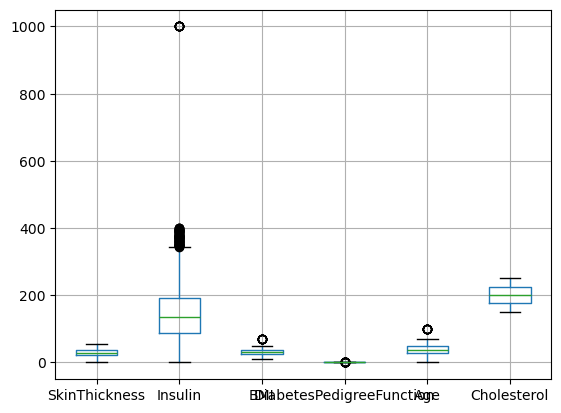

Initial rows: 999


In [4]:
k = []
for i in clean: k.append(i)
for i in k :
    clean[i] = pd.to_numeric(clean[i],errors = 'coerce')     


# clean.boxplot(k[0:4])
print("Initial rows:", len(clean)-1)
for i in k:
    q1 = clean[i].quantile(0.25)
    q3 = clean[i].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper =  q3+1.5*iqr
    # clean = clean[clean[i].between(q1 - 1.5*iqr, q3+1.5*iqr)]
    out = clean[~clean[i].between(lower,upper)]
    # print(out)
ranges = {
    'Age': (0, 100),
    'Glucose': (40, 300),
    'BloodPressure': (40, 200),
    'BMI': (10, 70),
    'HeartRate': (30, 220),
    'SkinThickness': (0, 100),
    'Insulin': (0, 1000),
    'Pregnancies' : (0, max(clean['Pregnancies']))
}
# print(max(clean['Pregnancies']))
for col, (low,high) in ranges.items():
    clean[col] = clean[col].clip(low,high)
    clean.loc[~clean[col].between(low,high),col] = np.nan
    clean.fillna(clean.median(), inplace = True)
    
clean.boxplot(k[3:9])
plt.show()
# clean.head(60)
print("Initial rows:", len(clean)-1)
# clean.head(60)

In [5]:
clean.info()
clean.isnull().sum()
clean.describe()
clean.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1014
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   float64
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   float64
 8   Cholesterol               1000 non-null   int64  
 9   SodiumLevel               1000 non-null   float64
 10  HeartRate                 1000 non-null   float64
 11  VitaminD                  1000 non-null   float64
 12  ExerciseHrsPerWeek        1000 non-null   float64
 13  Outcome                   1000 non-null   float64
dtypes: float64(13

(1000, 14)

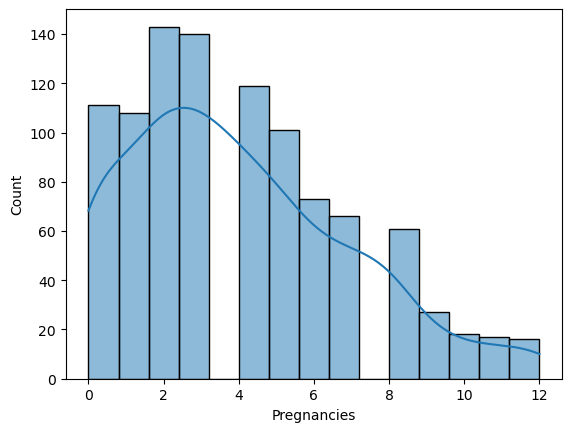

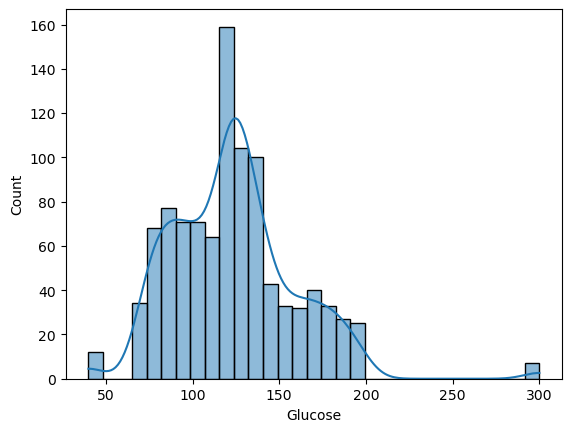

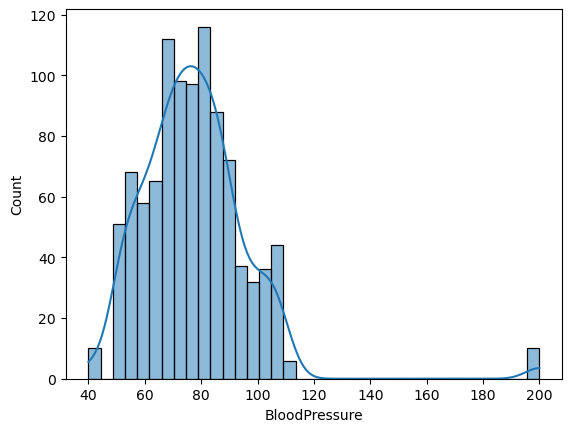

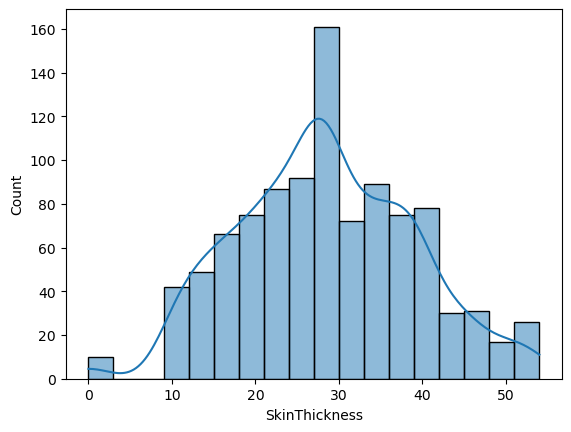

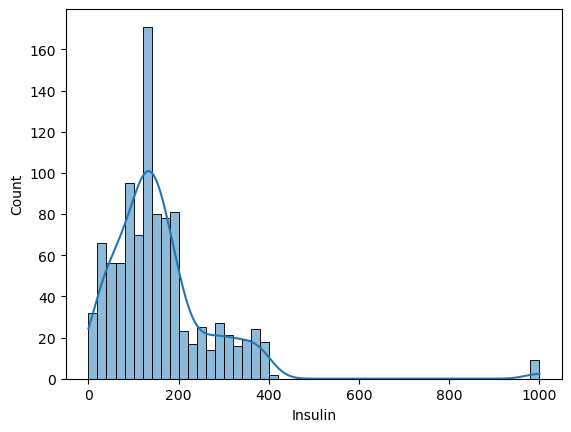

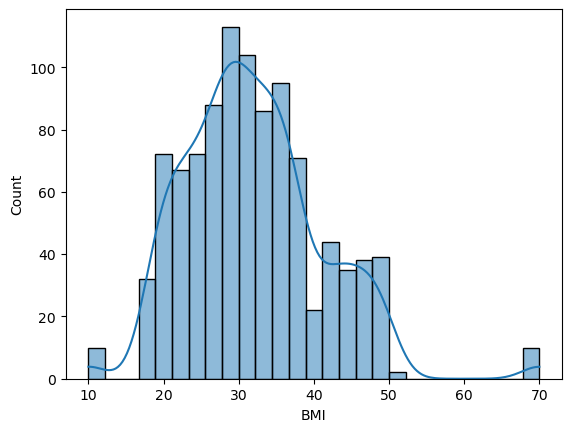

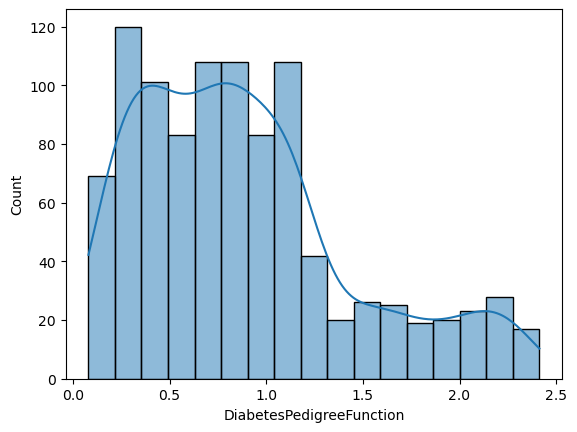

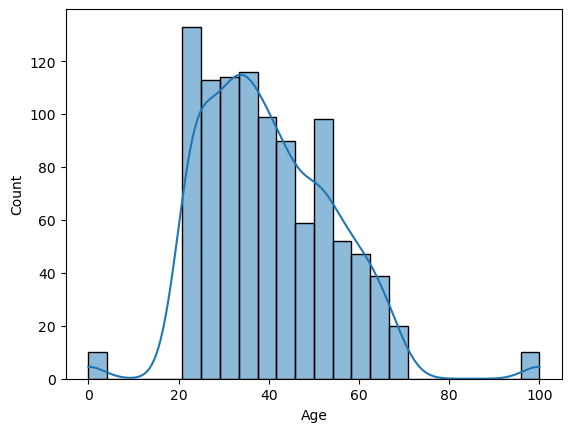

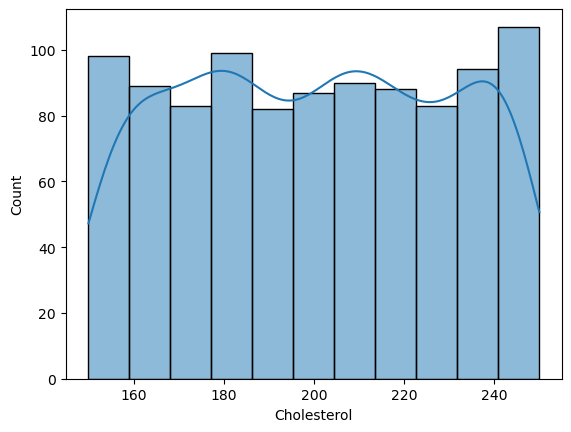

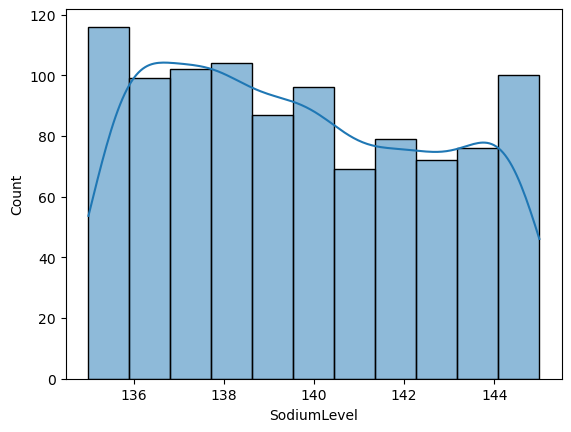

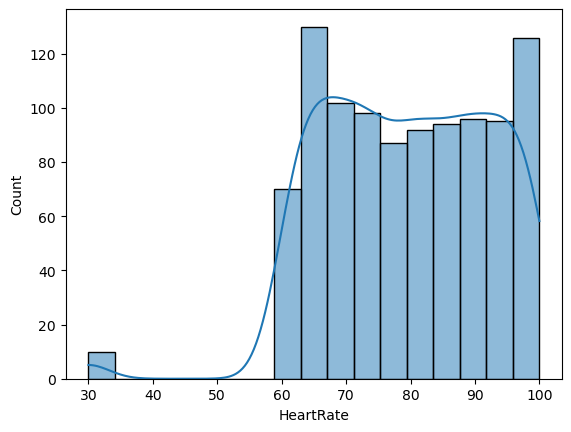

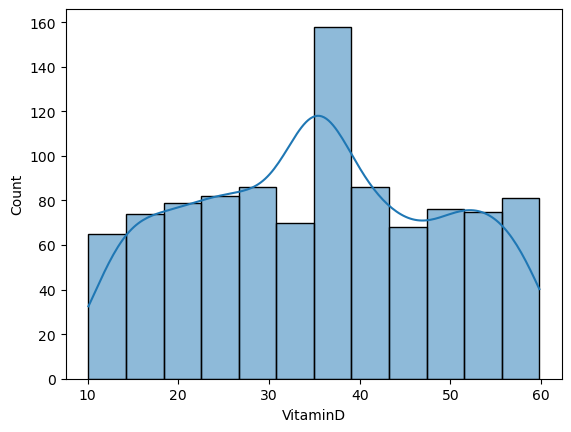

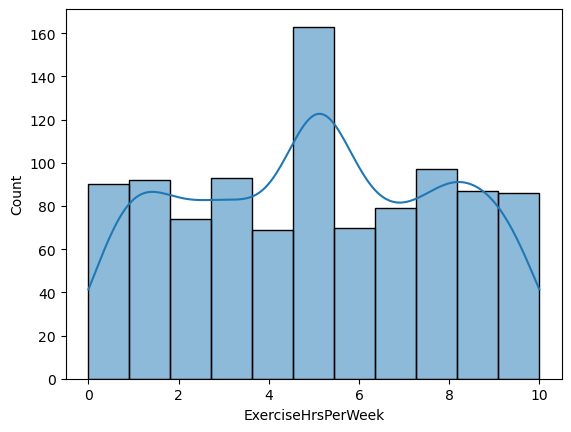

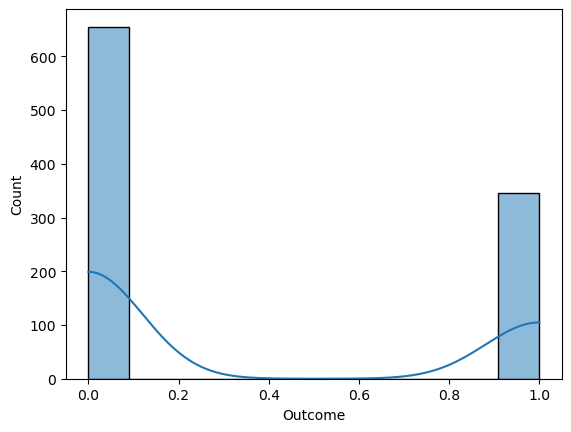

In [6]:
for i in k:
    sns.histplot(clean[i].dropna(), kde = True)
    plt.show()

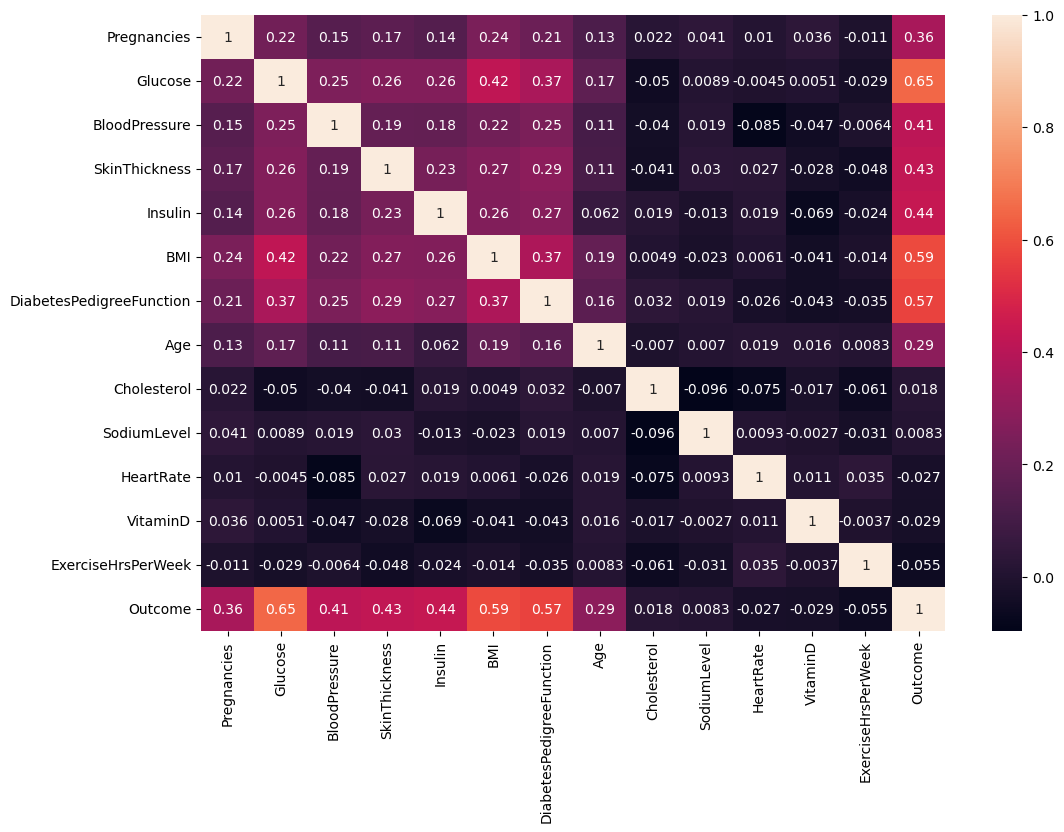

In [7]:
corr = clean.corr()
plt.figure(figsize = (12,8))
sns.heatmap(corr, annot = True)
plt.show()

# Observations
# Glucose has the highest positive correlation with diabetes (0.65), making it the strongest predictor.
# BMI (0.59) and Diabetes Pedigree Function (0.57) also show strong positive relationships with diabetes.
# Insulin, Skin Thickness, and Blood Pressure show moderate positive correlations.
# Cholesterol, Sodium Level, Heart Rate, Vitamin D, and Exercise Hours per Week have very weak correlations with diabetes.

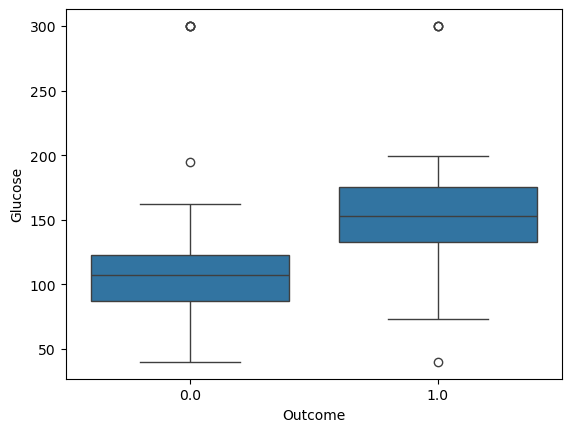

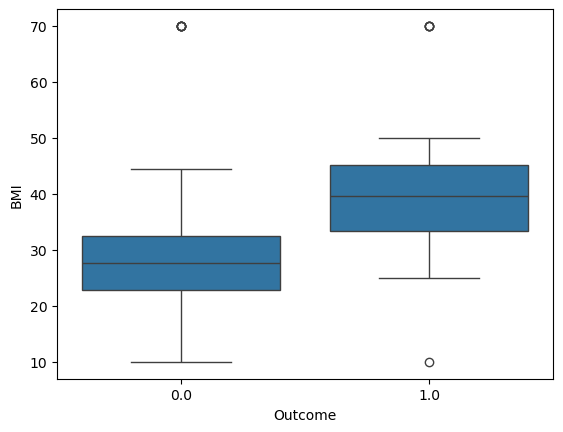

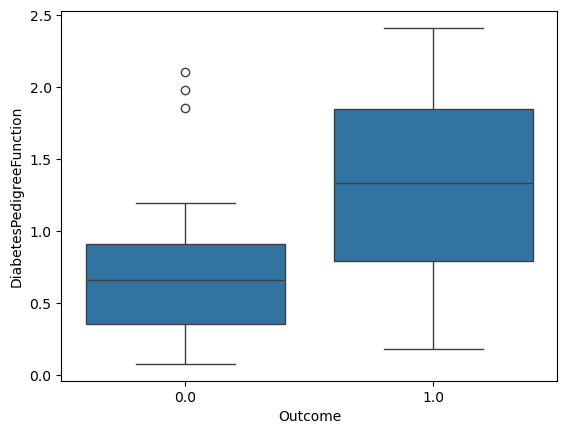

In [8]:
for i in ['Glucose', 'BMI', 'DiabetesPedigreeFunction']:
    sns.boxplot(x='Outcome', y=i, data=clean)
    plt.show()

Yes
Yes
Yes
Yes
Yes


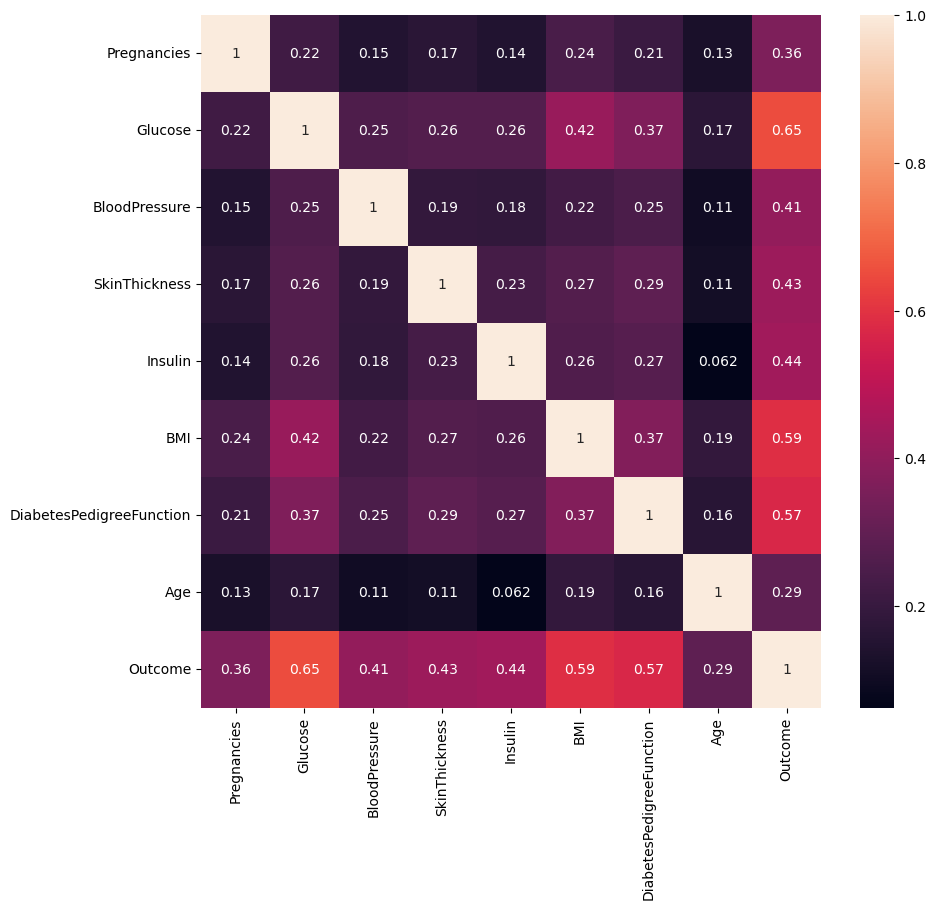

In [19]:
for i in clean:
    if(abs(clean[i].corr(clean["Outcome"])) <=0.1):
        print("Yes")
        clean = clean.drop(columns = i)
clean
plt.figure(figsize=(10,9))
sns.heatmap(clean.corr(numeric_only=True),annot = True)
plt.show()

In [28]:
x = clean.drop(columns = ["Outcome"])
y = clean["Outcome"]

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy of the model: ",accuracy_score(y_pred,y_test)*100,"%")
print("Classification Metrics: \n",classification_report(y_pred,y_test))

Accuracy of the model:  93.0 %
Classification Metrics: 
               precision    recall  f1-score   support

         0.0       0.95      0.94      0.95       129
         1.0       0.89      0.92      0.90        71

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200

